# Reported figures

Thesis Figures 2–6 use paired-difference point plots and percentage-based
assessment distributions. This notebook retains their layouts, axes, colours
and reported annotations. For the public example, run notebooks 05, 06 and 06a first.

The public baseline plot uses saved RFC Azure retrieval and source-checked page
grades. Configuration and answer-quality plots use illustrative inputs.
Private inputs and figures remain under ignored `local/`. No model request
or reassessment is made.


In [1]:
import hashlib
import json
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import display

from rag_comparison.artifacts import (
    read_jsonl,
    verify_artifacts,
    write_analysis_manifest,
)
from rag_comparison.figure_layout import (
    grade_distribution_figure,
    correctness_change_figure,
)
from rag_comparison.config import MIN_AGGREGATE_CASES


## Bound calculation inputs

Both calculation folders must bind the same input manifest. Figure data contains
only plotted observations, denominators and the declared direction. For accepted
data, use executed notebook copies under `local/`.

In [2]:
data_dir = Path("../examples/evaluation")
analysis_dir = Path("../local/evaluation/reported_example")
tables_dir = Path("../local/evaluation/reported_tables_example")
output_dir = Path("../local/evaluation/reported_figures_example")

manifest_path = data_dir / "manifest.json"
manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
input_paths = verify_artifacts(data_dir, manifest)
answerable_n = sum(row["cohort"] == "A" for row in read_jsonl(input_paths["questions"]))
input_sha = hashlib.sha256(manifest_path.read_bytes()).hexdigest()
kind = manifest["metadata"]["dataset_kind"]
assert kind in ("illustrative", "accepted")
if kind == "accepted":
    assert data_dir.resolve().is_relative_to(Path("../local").resolve())
assert output_dir.resolve().is_relative_to(Path("../local").resolve())
output_dir.mkdir(parents=True, exist_ok=True)

calculation_paths = []
for folder in (analysis_dir, tables_dir):
    binding = json.loads((folder / "analysis_manifest.json").read_text())
    assert binding["input_manifest_sha256"] == input_sha
    calculation_paths.append(verify_artifacts(folder, binding))
analysis = json.loads(
    calculation_paths[0]["reported_analysis"].read_text(encoding="utf-8")
)
table_result = json.loads(
    calculation_paths[1]["reported_tables"].read_text(encoding="utf-8")
)
assert analysis["dataset_kind"] == table_result["dataset_kind"] == kind
tables = table_result["tables"]
figure_data = {}
figure_files = {}
print({"dataset_kind": kind, "model_requests": 0})

{'dataset_kind': 'illustrative', 'model_requests': 0}


In [3]:
labels = {
    "C-CHUNK-STRUCT-800-0": "C-CHUNK",
    "G-CHUNK-STRUCT-800-0": "G-CHUNK",
    "C-EMBED-LARGE-1536": "C-EMBED",
    "G-EMBED-LARGE-1536": "G-EMBED",
    "G-ENTITY-POLICY-PROCESS-ROLE": "G-ENTITY",
}
point_colours = ["#1B6389", "#A74C26", "#4D6B35", "#735284", "#333333"]
point_shapes = ["o", "s", "D", "^", "P"]
illustrative = kind == "illustrative"
prefix = "Illustrative: " if illustrative else ""
plt.rcParams.update(
    {
        "font.family": "Arial",
        "font.size": 10,
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 10,
        "svg.fonttype": "none",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.unicode_minus": False,
        "figure.facecolor": "white",
        "savefig.facecolor": "white",
    }
)


def save_figure(number, fig):
    filename = f"figure_{number:02d}.png"
    fig.savefig(output_dir / filename, dpi=600)
    figure_files[f"figure_{number:02d}"] = filename
    display(fig)
    plt.close(fig)


def paired_effect_figure(rows, value_key, title, xlabel, incomplete=False):
    fig, ax = plt.subplots(figsize=(160 / 25.4, 4.15))
    fig.subplots_adjust(left=0.20, right=0.73, bottom=0.27, top=0.80)
    ax.axvline(0, color="#444444", linewidth=1.2, zorder=1)
    for index, row in enumerate(rows):
        missing = incomplete and row["paired_k"] < row["applicable_n"]
        ax.scatter(
            row[value_key],
            index,
            s=52,
            marker=point_shapes[index],
            edgecolors=point_colours[index],
            facecolors="white" if missing else point_colours[index],
            zorder=3,
        )
        ax.text(
            1.035,
            index,
            f"{row[value_key]:+.4f}" + ("†" if missing else ""),
            transform=ax.get_yaxis_transform(),
            ha="left",
            va="center",
            fontsize=9,
        )
        ax.text(
            1.035,
            index + 0.29,
            f"k={row['paired_k']}/{row['applicable_n']}",
            transform=ax.get_yaxis_transform(),
            ha="left",
            va="center",
            fontsize=8,
            color="#555555",
        )
    limit = 0.2
    if illustrative:
        import math

        limit = max(
            0.2, math.ceil(max(abs(row[value_key]) for row in rows) / 0.2) * 0.2
        )
    ax.set(
        yticks=range(len(rows)),
        yticklabels=[labels[row["condition_id"]] for row in rows],
        ylim=(len(rows) - 0.4, -0.6),
        xlim=(-limit, limit),
        xticks=[-limit, -limit / 2, 0, limit / 2, limit],
    )
    ax.grid(axis="x", color="#DDDDDD", linewidth=0.6)
    ax.tick_params(axis="y", length=0)
    ax.spines["left"].set_visible(False)
    ax.set_xlabel(xlabel, labelpad=10)
    fig.suptitle(prefix + title, x=0.025, y=0.98, ha="left", fontsize=14, weight="bold")
    fig.text(
        0.025,
        0.875,
        "Paired effects against each variant's own baseline",
        fontsize=10,
        color="#555555",
    )
    note = "† Incomplete retrieval." if incomplete else "No ordinal means."
    fig.text(
        0.025,
        0.02,
        f"C variants vs C0. G variants vs G0. Answerable questions (N={answerable_n}).\n"
        + note
        + "\nDescriptive only. No intervals or statistical significance claims.",
        ha="left",
        va="bottom",
        fontsize=9,
        linespacing=1.35,
    )
    return fig

## Baseline retrieval differences — Figure 2

Sort the common-valid question differences; positive values favour G0.
The public RFC example has three pairs, so it shows individual values and counts
without an aggregate effect. Accepted study inputs use their PRIMARY baseline;
the mean uses the paired population when the minimum case count is met.
See thesis Section 3.2.


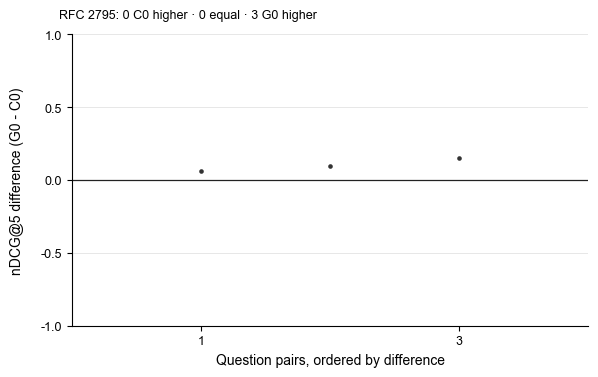

In [4]:
public_rfc_baseline = analysis.get("public_rfc_baseline")
baseline = (
    public_rfc_baseline["result"]
    if public_rfc_baseline is not None
    else next(
        row["result"]
        for row in analysis["contrasts"]
        if (row["scope"], row["reference"], row["variant"], row["metric"])
        == ("PRIMARY", "C0", "G0", "ndcg_at_5")
    )
)
ordered = sorted(baseline["question_changes"].items(), key=lambda row: (row[1], row[0]))
differences = [value for _, value in ordered]
assert len(differences) == baseline["k"]
mean_difference = (
    sum(differences) / len(differences)
    if len(differences) >= MIN_AGGREGATE_CASES
    else None
)
figure_data["Figure 2"] = {
    "scope": "RFC2795" if public_rfc_baseline is not None else "PRIMARY",
    "direction": "G0 minus C0",
    "paired_k": len(differences),
    "question_differences": dict(ordered),
    "mean_difference": mean_difference,
    "negative_equal_positive": [
        sum(value < 0 for value in differences),
        sum(value == 0 for value in differences),
        sum(value > 0 for value in differences),
    ],
}

fig, ax = plt.subplots(figsize=(160 / 25.4, 100 / 25.4))
fig.subplots_adjust(left=0.16, right=0.98, bottom=0.12, top=0.86)
ax.scatter(
    range(1, len(differences) + 1), differences, s=11, color="#333333", linewidths=0
)
ax.axhline(0, color="#222222", linewidth=0.9)
if mean_difference is not None:
    ax.axhline(mean_difference, color="#777777", linestyle="--", linewidth=1)
ticks = (
    [1, 50, 100, 150, len(differences)]
    if len(differences) > 150
    else [1, len(differences)]
)
ax.set(
    xlim=(0, len(differences) + 1),
    ylim=(-1, 1),
    xlabel="Question pairs, ordered by difference",
    ylabel="nDCG@5 difference (G0 - C0)",
    xticks=ticks,
    yticks=[-1, -0.5, 0, 0.5, 1],
)
ax.tick_params(axis="y", labelsize=9)
ax.yaxis.labelpad = 12
ax.grid(axis="y", color="#DDDDDD", linewidth=0.5)
ax.set_axisbelow(True)
negative, equal, positive = figure_data["Figure 2"]["negative_equal_positive"]
fig.text(
    0.14,
    1 - 28 / (100 / 25.4 * 72),
    ("RFC 2795: " if public_rfc_baseline is not None else prefix)
    + f"{negative} C0 higher · {equal} equal · {positive} G0 higher",
    fontsize=9,
    va="baseline",
)
if mean_difference is not None:
    ax.annotate(
        f"Paired mean difference: {mean_difference:+.4f}",
        xy=(0.9826, mean_difference),
        xycoords=("axes fraction", "data"),
        xytext=(0, -16.2),
        textcoords="offset points",
        ha="right",
        va="baseline",
        fontsize=9,
    )
save_figure(2, fig)


## Single-factor retrieval effects — Figure 3

Each condition is compared with its architecture's unchanged baseline on PRIMARY.
The plotted mean differences use the calculation's full precision. The corresponding
paired counts and rounded values appear in Table 11. See thesis Section 3.4.1.

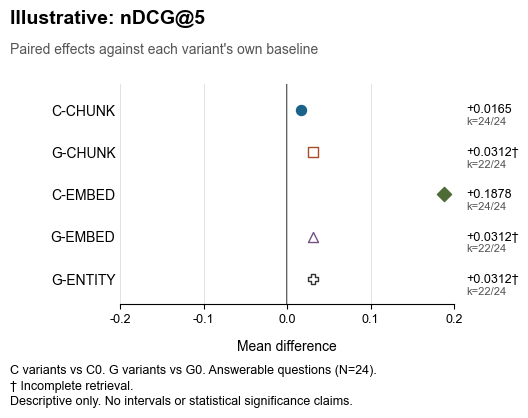

In [5]:
retrieval_rows = tables["Table 11: retrieval changes and behaviour"]
effects = []
for row in retrieval_rows:
    result = next(
        item["result"]
        for item in analysis["contrasts"]
        if (item["scope"], item["reference"], item["variant"], item["metric"])
        == ("PRIMARY", row["Reference"], row["Variant"], "ndcg_at_5")
    )
    assert result["k"] == row["Retrieval pair k"]
    difference = result["standard"]["estimate"] if result["standard"] else None
    effects.append(
        {
            "condition_id": row["Variant"],
            "reference": row["Reference"],
            "paired_k": result["k"],
            "applicable_n": result["N_app"],
            "mean_difference": difference,
        }
    )
figure_data["Figure 3"] = {
    "scope": "PRIMARY",
    "direction": "variant minus baseline",
    "effects": effects,
}

plotted = [row for row in effects if row["mean_difference"] is not None]
fig = paired_effect_figure(
    plotted, "mean_difference", "nDCG@5", "Mean difference", incomplete=True
)
save_figure(3, fig)

## Correctness balances — Figure 4

Ordinal grades define higher, equal and lower outcomes without numerical spacing.
Dominance is `(wins - losses) / k`; ties remain in `k`. Positive values favour the
variant. See thesis Table 12 and Figure 4.

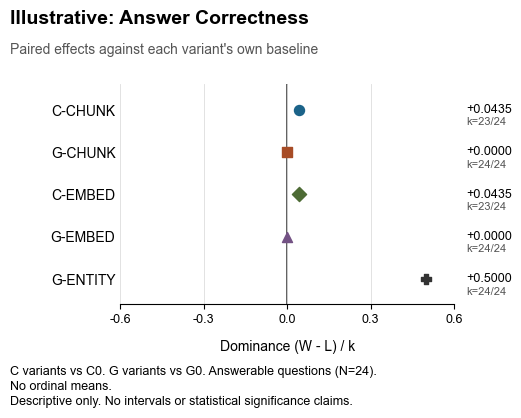

In [6]:
quality = [
    row
    for row in tables["Table 12: paired quality changes"]
    if row["Measure"] == "answer_correctness"
]
balances = []
for row in quality:
    k = row["Wins"] + row["Ties"] + row["Losses"]
    assert k == row["Paired k"]
    balances.append(
        {
            "condition_id": row["Variant"],
            "paired_k": k,
            "applicable_n": answerable_n,
            "wins": row["Wins"],
            "ties": row["Ties"],
            "losses": row["Losses"],
            "dominance": (row["Wins"] - row["Losses"]) / k,
        }
    )
figure_data["Figure 4"] = {
    "scope": "PRIMARY",
    "direction": "variant relative to baseline",
    "balances": balances,
}

fig = paired_effect_figure(
    balances, "dominance", "Answer Correctness", "Dominance (W - L) / k"
)
save_figure(4, fig)

## Applicable grade distributions — Figure 5

Each bar uses the condition's own applicable FINAL population. Correctness,
faithfulness and citation correctness therefore need not have the same count.
These distributions are separate from paired changes. See thesis Appendix E.

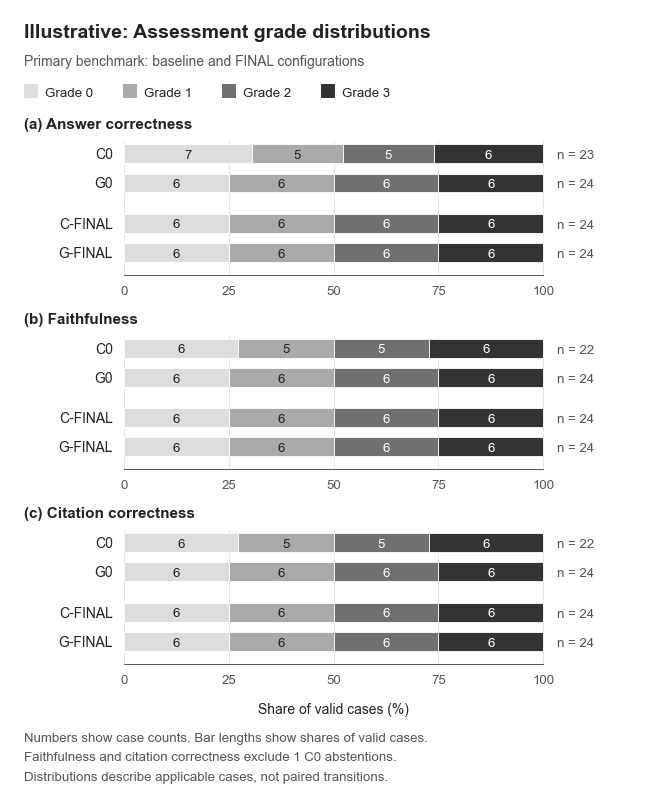

In [7]:
grade_rows = tables["Appendix E: grade distributions"]
figure_data["Figure 5"] = {
    "scope": "FINAL",
    "grade_order": [0, 1, 2, 3],
    "distributions": grade_rows,
}

fig = grade_distribution_figure(grade_rows, illustrative=illustrative)
save_figure(5, fig)

## Lower, equal and higher correctness — Figure 6

Plot the same paired cases as Figure 4 in the caption's lower/equal/higher order.
Counts preserve ties and cannot be read as changes in mean ordinal grade.
See thesis Appendix E.

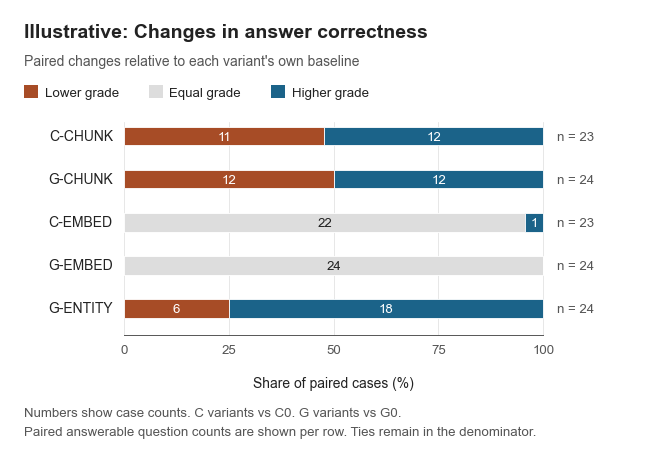

In [8]:
figure_data["Figure 6"] = {
    "scope": "PRIMARY",
    "category_order": ["lower", "equal", "higher"],
    "transitions": balances,
}

fig = correctness_change_figure(balances, labels, illustrative=illustrative)
save_figure(6, fig)

## Save figure data

The data file binds the plotted values to their input manifest. Plots remain
descriptive: shared evidence and benchmark selection limit population inference.
Original aggregates and figures require an agreed release decision before public
distribution. See [result reproduction](../docs/reproduction_matrix.md).

In [9]:
result = {
    "dataset_kind": kind,
    "input_manifest_sha256": input_sha,
    "figures": figure_data,
    "claim_status": "descriptive",
    "model_requests": 0,
}
target = output_dir / "reported_figures.json"
target.write_text(
    json.dumps(result, ensure_ascii=False, allow_nan=False, indent=2) + "\n",
    encoding="utf-8",
)
write_analysis_manifest(
    output_dir, manifest_path, {"figure_data": target.name, **figure_files}
)
print({"figures": len(figure_files), "data": target.name, "model_requests": 0})

{'figures': 5, 'data': 'reported_figures.json', 'model_requests': 0}
